### `precision_comparison.ipynb` 
*Created: September 23, 2026* <br/>
In this notebook we estimate the floating point error that occurs when computing the phi functions, using a high precision implementation as a reference. 

In [16]:
using LinearAlgebra, NBInclude, LaTeXStrings, CairoMakie, UnPack
@nbinclude("../../../../set_makie_defaults.ipynb")
@nbinclude("phi_contour.ipynb")

φ₃ (generic function with 1 method)

In [8]:
function phi_contour_high_precision(λ::Float64, k::Int; precision::Int = 256, M::Int = 64)
    """
  
    PARAMETERS
    ----------
    λ :: real number at which to evaluate the phi function
    k :: the phi function subscript
    M :: number of quadrature nodes 
    precision :: number of bits of significand precision for BigFloat arithmetic 
    """

    M > 0 || throw(ArgumentError("M must be positive."))
    0 ≤ k ≤ 3 || throw(ArgumentError("k must be 0,1,2 or 3."))
    precision ≥ 64 || throw(ArgumentError("precision must be at least 64 bits."))
    
    return setprecision(BigFloat, precision) do 

        λ_big = BigFloat(λ)
        r_big = BigFloat(1)

        #Note: 2 and M are 64-bit Ints, so no loss of precision when they get casted to BigFloats for precision ≥ 64
        half = BigFloat(1) / 2    
        Δθ = BigFloat(π) / M

        #These angles have type BigFloat
        θ = [Δθ*(j-half) for j in 1:M]

        #Contour points (Complex{BigFloat}'s)
        z = λ_big .+ r_big .* exp.(im .* θ)

        if k == 0 
            return real(sum(ϕ₀.(z)) / M)
        elseif k == 1 
            return real(sum(ϕ₁.(z)) / M)
        elseif k == 2 
            return real(sum(ϕ₂.(z)) / M)
        else
            return real(sum(ϕ₃.(z)) / M)
        end 
    end 
end

phi_contour_high_precision (generic function with 1 method)

In [9]:
function compare_precisions(λs::Vector{Float64}, k::Int, precision::Int = 256; M::Int = 64)
  
    #Compare Float64 evaluation against a BigFloat reference, using the specified precision. 

    return setprecision(BigFloat, precision) do 

        #These operations use Float64 arithmetic. **See "Important Note" below!**
        phis_reg_precision = [phi_contour(λ, k; M = M) for λ in λs]
        
        #Compute phis in high precision 
        phis_high_precision = [phi_contour_high_precision(λ, k; precision = precision, M = M) for λ in λs]
                              
        #=Important Note!
        - The types of the operands determine the arithmetic used. 
        - The setprecision block only controls the precision of operations that already involve BigFloats!
         Since the elements of `λs` are Float64s (not BigFloat's), the computation within the 
         array comprehension is regular old Float64 arithmetic.  
        =#

        #Now compute relative errors, converting `phis_reg_precision` to high precision before the subtraction,
        #so that the relative errors are computed in high precision. 
        rel_errors = abs.((phis_high_precision .- BigFloat.(phis_reg_precision)) ./ phis_high_precision)

        return (phis_reg_precision, phis_high_precision, rel_errors)
    end 
end 

compare_precisions (generic function with 2 methods)

In [13]:
λs = exp.(1:-2:-32)
_, _, rel_errors_1 = compare_precisions(λs, 1, 256; M = 128);
_, _, rel_errors_2 = compare_precisions(λs, 2, 256; M = 128);
_, _, rel_errors_3 = compare_precisions(λs, 3, 256; M = 128);

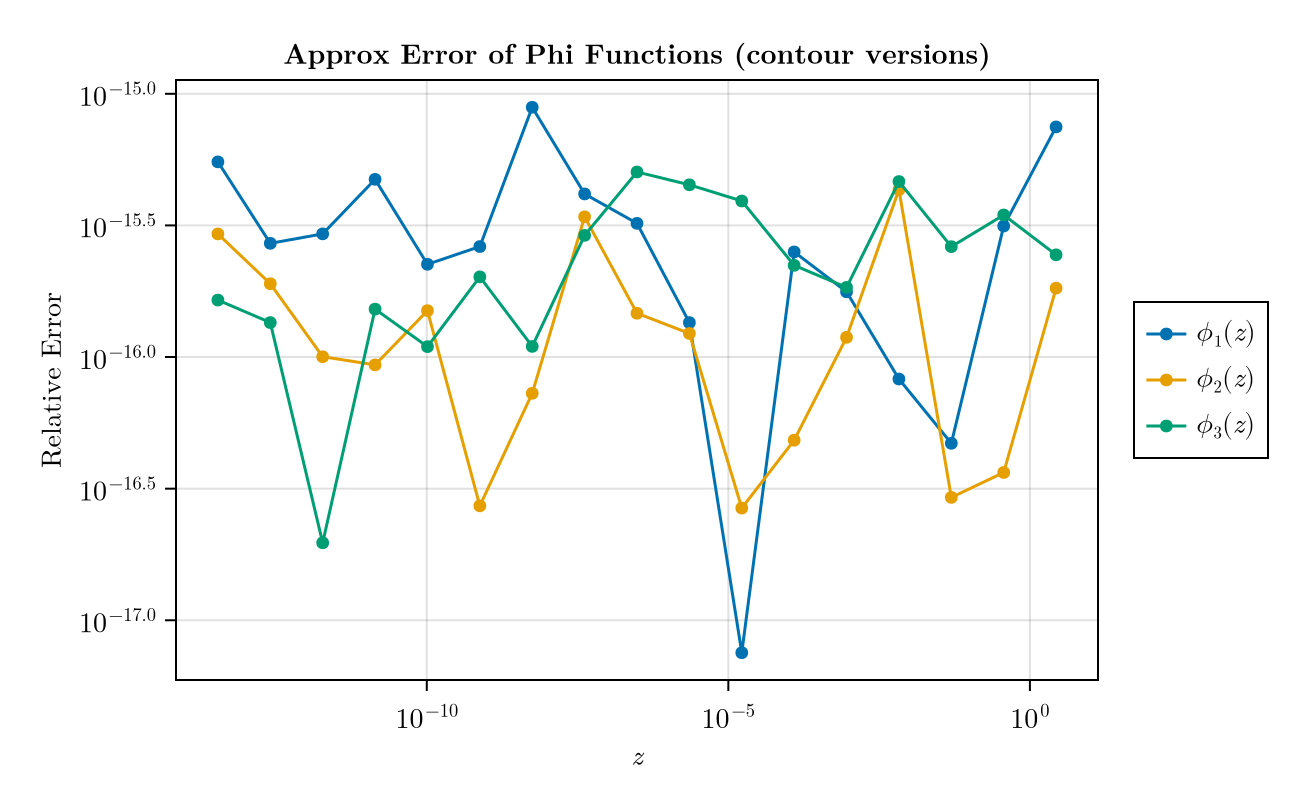

CairoMakie.Screen{IMAGE}


In [14]:
fig = Figure(size = (650,400))
ax = Axis(fig[1,1], xlabel = L"z", ylabel = "Relative Error", title = "Approx Error of Phi Functions (contour versions)",
          xscale = log10, yscale = log10)

scatterlines!(ax, λs, rel_errors_1, label = L"\phi_1(z)")
scatterlines!(ax, λs, rel_errors_2, label = L"\phi_2(z)")
scatterlines!(ax, λs, rel_errors_3, label = L"\phi_3(z)")

Legend(fig[1,2], ax)
display(fig)

In [15]:
λs = exp.(1:-2:-32)

quadrature_differences = setprecision(BigFloat, 256) do
    
    ref64 = [phi_contour_high_precision(λ, 3; M=64, precision=256) for λ in λs]
    ref128 = [phi_contour_high_precision(λ, 3; M=128, precision=256) for λ in λs]
    abs.((ref64 .- ref128) ./ ref128)
end

#Conclusion: quadrature error is negligible at Float64 precision for these inputs 

17-element Vector{BigFloat}:
 2.240691723491631159732644441357960510081800865861100690174336494417715952128924e-77
 1.178543935388170454524123841195785006572102500611745243752558858025686984919864e-77
 0.0
 1.293243892104704994159499399218509670003963101722525952414166957006145629676123e-77
 6.475649889957992435976038248031087428043903541975429753730189990769286441473988e-77
 0.0
 2.590839748634628670255289965533533379487338942559169796626665689238710919506348e-77
 3.886273653726851541518327742382949780504978791132834560694639721247330592587672e-77
 0.0
 3.886275809570150224283249315961351788308451306440722971955242035706296483996764e-77
 1.295425281449665653774221976073972638631983398497304608672459106537415484277452e-77
 1.295425283018600681562376809538239537080298072825405174977693040958696618744614e-77
 3.886275849692798843958968371733743035473236397824742253632484431683397190654214e-77
 3.886275849779006986212446810750813513342953632924862822659319738844059382086862e-77
 0.0
 2.59

In [ ]:
function phi1(z::Float64; precision::Int = 64)
    """
    Compute ϕ₁(z) = (e^z - 1) / z in high precision.

    z :: value at which to evaluate ϕ₀
    precision :: number of bits in the BigFloat significand 

    Approximate Decimal Precision:
        64 bits ≈ 19 decimal digits
        256 bits ≈ 77 decimal digits 
    
       log10(2.0^64) = 19.2659...
       log10(2.0^256) ≈ 77.0

    Note: Float64 uses 64 bits of storage, but has 53 bits of significand precision, 
          corresponding to roughly 16 decimal digits.
    """

    return setprecision(BigFloat, precision) do 

        #Convert z to a BigFloat of the desired precision
        z_big = BigFloat(z)   

        if iszero(z_big)
            return one(z_big)
        end 
    
        return expm1(z_big) / z_big
    end 
end 


function precision_comparison(zvals::Vector{Float64}, precision)
  
    #Compare Float64 evaluation against a BigFloat reference, using the specified precision. 

    return setprecision(BigFloat, precision) do 

        #Compute phis in high precision 
        phis_high_precision = [phi(z; precision = precision) for z in zvals]

        #These operations use Float64 arithmetic. **See "Important Note" below!**
        phis_reg_precision = [iszero(z) ? one(z) : expm1(z) / z for z in zvals]

        #This gives catastrophic cancellation near for very small |z| 
        #phis_reg_precision = [iszero(z) ? one(z) : (exp(z) - 1) / z for z in zvals]

        #=Important Note!
        - The types of the operands determine the arithmetic used. 
        - The setprecision block only controls the precision of operations that already involve BigFloats!
         Since the elements of `zvals` are Float64s (not BigFloat's), the computation within the 
         array comprehension is regular old Float64 arithmetic.  
        =#

        #Now compute relative errors, converting `phis_reg_precision` to high precision before the subtraction,
        #so that the relative errors are computed in high precision. 
        rel_errors = abs.((phis_high_precision .- BigFloat.(phis_reg_precision)) ./ phis_high_precision)

        return rel_errors
    end 
end 